In [25]:
import pandas as pd
import os 
import numpy as np
import joblib

train = pd.read_csv('data/interim/train_residuals.csv', index_col = 0)
test = pd.read_csv('data/interim/test_residuals.csv', index_col = 0)


In [26]:
import os
os.makedirs('figures', exist_ok = True)

In [27]:
train.info()

<class 'pandas.DataFrame'>
Index: 796 entries, 2629 to 2500
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HAGRID                            796 non-null    int64  
 1   Kingdom                           796 non-null    str    
 2   Phylum                            796 non-null    str    
 3   Class                             796 non-null    str    
 4   Order                             796 non-null    str    
 5   Family                            796 non-null    str    
 6   Genus                             796 non-null    str    
 7   Species                           796 non-null    str    
 8   Common name                       796 non-null    str    
 9   Female maturity (days)            638 non-null    float64
 10  Male maturity (days)              453 non-null    float64
 11  Gestation/Incubation (days)       680 non-null    float64
 12  Weaning (days)      

In [28]:
train2 = train.dropna(subset = ['Metabolic rate (W)'])
test2 = test.dropna(subset = ['Metabolic rate (W)'])

print(train2['Order'].value_counts(normalize = True).sort_index())
print(test2['Order'].value_counts(normalize = True).sort_index())

Order
Afrosoricida       0.014134
Artiodactyla       0.056537
Carnivora          0.155477
Cetacea            0.003534
Chiroptera         0.102473
Cingulata          0.021201
Dasyuromorphia     0.053004
Didelphimorphia    0.028269
Diprotodontia      0.063604
Erinaceomorpha     0.014134
Hyracoidea         0.003534
Lagomorpha         0.014134
Macroscelidea      0.010601
Monotremata        0.007067
Peramelemorphia    0.017668
Perissodactyla     0.003534
Pilosa             0.010601
Primates           0.070671
Proboscidea        0.003534
Rodentia           0.310954
Scandentia         0.003534
Sirenia            0.003534
Soricomorpha       0.028269
Name: proportion, dtype: float64
Order
Afrosoricida       0.016949
Artiodactyla       0.033898
Carnivora          0.118644
Chiroptera         0.050847
Cingulata          0.016949
Dasyuromorphia     0.050847
Didelphimorphia    0.033898
Diprotodontia      0.016949
Erinaceomorpha     0.016949
Lagomorpha         0.016949
Macroscelidea      0.016949
Mon

In [29]:
train2['mass_specific_BMR'] = train2['Metabolic rate (W)'] / train2['Body mass (g)']
test2['mass_specific_BMR'] = test2['Metabolic rate (W)'] / test2['Body mass (g)']


In [30]:
train2.isnull().sum()

HAGRID                                0
Kingdom                               0
Phylum                                0
Class                                 0
Order                                 0
Family                                0
Genus                                 0
Species                               0
Common name                           0
Female maturity (days)               28
Male maturity (days)                 78
Gestation/Incubation (days)          20
Weaning (days)                       66
Litter/Clutch size                    2
Litters/Clutches per year            59
Inter-litter/Interbirth interval    102
Birth weight (g)                     48
Weaning weight (g)                  143
Adult weight (g)                      0
Growth rate (1/days)                180
Maximum longevity (yrs)               0
Specimen origin                       0
Sample size                           0
Data quality                          0
Metabolic rate (W)                    0


In [31]:
cols_to_check = ['Female maturity (days)','Male maturity (days)', 'Gestation/Incubation (days)',
                'Weaning (days)', 'Litters/Clutches per year', 'Inter-litter/Interbirth interval',
                 'Birth weight (g)', 'Weaning weight (g)', 'Growth rate (1/days)', 'Temperature (K)']
                
for col in cols_to_check:
    genus_cov = train2.groupby('Genus')[col].count().gt(0).mean()
    fam_cov = train2.groupby('Family')[col].count().gt(0).mean()

    print(f'{col}:genus coverage = {genus_cov:.2f}, family coverage = {fam_cov:.2f}')

Female maturity (days):genus coverage = 0.92, family coverage = 0.97
Male maturity (days):genus coverage = 0.76, family coverage = 0.90
Gestation/Incubation (days):genus coverage = 0.94, family coverage = 0.98
Weaning (days):genus coverage = 0.81, family coverage = 0.88
Litters/Clutches per year:genus coverage = 0.81, family coverage = 0.87
Inter-litter/Interbirth interval:genus coverage = 0.66, family coverage = 0.78
Birth weight (g):genus coverage = 0.85, family coverage = 0.94
Weaning weight (g):genus coverage = 0.52, family coverage = 0.64
Growth rate (1/days):genus coverage = 0.41, family coverage = 0.59
Temperature (K):genus coverage = 0.91, family coverage = 0.95


In [32]:
train2 = train2.drop(['Weaning weight (g)', 'Growth rate (1/days)'], axis = 1)
test2 = test2.drop(['Weaning weight (g)', 'Growth rate (1/days)'], axis = 1)
train2.columns

Index(['HAGRID', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus',
       'Species', 'Common name', 'Female maturity (days)',
       'Male maturity (days)', 'Gestation/Incubation (days)', 'Weaning (days)',
       'Litter/Clutch size', 'Litters/Clutches per year',
       'Inter-litter/Interbirth interval', 'Birth weight (g)',
       'Adult weight (g)', 'Maximum longevity (yrs)', 'Specimen origin',
       'Sample size', 'Data quality', 'Metabolic rate (W)', 'Body mass (g)',
       'Temperature (K)', 'residual', 'mass_specific_BMR'],
      dtype='str')

In [33]:
train2.to_csv('data/processed/train2.csv')
test2.to_csv('data/processed/test2.csv')

In [34]:
X2_train = train2[['Female maturity (days)', 'Male maturity (days)', 
                  'Gestation/Incubation (days)', 'Weaning (days)',
       'Litter/Clutch size', 'Litters/Clutches per year', 
    'Inter-litter/Interbirth interval', 'Birth weight (g)',
       'Temperature (K)', 'mass_specific_BMR']]
 
y2_train = train2['residual']

X2_test = test2[['Female maturity (days)', 'Male maturity (days)', 
                  'Gestation/Incubation (days)', 'Weaning (days)',
       'Litter/Clutch size', 'Litters/Clutches per year', 
    'Inter-litter/Interbirth interval', 'Birth weight (g)',
       'Temperature (K)', 'mass_specific_BMR']]

y2_test = test2['residual']

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

class TaxonomicalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, taxonomy_df):
        self.taxonomy_df = taxonomy_df

    def fit(self, X, y=None):
        self.genus_medians_ = {}
        self.family_medians_ = {}
        self.order_medians_ = {}
        self.column_medians_ = {}

        for col in X.columns:
            tax = self.taxonomy_df.loc[X.index]
            self.genus_medians_[col] = X.groupby(tax['Genus'])[col].median()
            self.family_medians_[col] = X.groupby(tax['Family'])[col].median()
            self.order_medians_[col] = X.groupby(tax['Order'])[col].median()
            self.column_medians_[col] = X[col].median()
        return self

    def transform(self, X):
        X_copy = X.copy()
        tax = self.taxonomy_df.loc[X.index]

        for col in X.columns:
            X_copy[col] = X_copy[col].fillna(tax['Genus'].map(self.genus_medians_[col]))
            X_copy[col] = X_copy[col].fillna(tax['Family'].map(self.family_medians_[col]))
            X_copy[col] = X_copy[col].fillna(tax['Order'].map(self.order_medians_[col]))
            X_copy[col] = X_copy[col].fillna(self.column_medians_[col])
        return X_copy   



In [36]:
all_taxonomy = pd.concat([train2,test2])

pipe2 = Pipeline([
    ('imputer', TaxonomicalImputer(taxonomy_df = all_taxonomy)),
    ('model2', RandomForestRegressor(random_state = 42))
])

#Grid Search CV

from sklearn.model_selection import GridSearchCV, RepeatedKFold
import joblib

param_grid = {
    'model2__n_estimators': [200,500],
    'model2__max_features': ['sqrt', 0.3, 0.5, 0.7, 1.0],
    'model2__min_samples_leaf': [1,2,4,8],
}

cv_grid = RepeatedKFold(n_splits = 10, n_repeats = 3, random_state = 42)

grid = GridSearchCV(
    pipe2,
    param_grid,
    cv = cv_grid,
    scoring = {'r2': 'r2', 'mae' : 'neg_mean_absolute_error'},
    refit = 'r2',
    n_jobs = 1,
    verbose = 2   
)

grid.fit(X2_train, y2_train)

joblib.dump(grid, 'grid_results.pkl')

In [37]:
import joblib
import numpy as np

grid = joblib.load('grid_results.pkl')

best_index = grid.best_index_
n = grid.n_splits_

fold_r2 = np.array([grid.cv_results_[f'split{i}_test_r2'][best_index]for i in range(n)])
fold_mae = -np.array([grid.cv_results_[f'split{i}_test_mae'][best_index]for i in range(n)])

print(f'Best parameters: {grid.best_params_}')
print(f'Best CV R² Score: {grid.best_score_:.3f}')
print(f'R² Scores across folds with the best parameters ranged from: {fold_r2.min():.3f} - {fold_r2.max():.3f}')
print(f'Best CV MAE: {fold_mae.mean():.3f}')
print(f'With best parameters, CV Predictions lie within a factor of {10**fold_mae.mean():.2f} of true value')
print(f'MAE across folds with the best parameters ranged from: {fold_mae.min():.3f} - {fold_mae.max():.3f}')

Best parameters: {'model2__max_features': 0.5, 'model2__min_samples_leaf': 1, 'model2__n_estimators': 200}
Best CV R² Score: 0.517
R² Scores across folds with the best parameters ranged from: 0.225 - 0.685
Best CV MAE: 0.125
With best parameters, CV Predictions lie within a factor of 1.33 of true value
MAE across folds with the best parameters ranged from: 0.089 - 0.190


In [38]:
all_config_r2 = grid.cv_results_['mean_test_r2']

print(f'Mean R² scores of all {len(all_config_r2)} configurations ranged from: {all_config_r2.min():.3f} - {all_config_r2.max():.3f}')

Mean R² scores of all 40 configurations ranged from: 0.471 - 0.517


In [39]:
best_model = grid.best_estimator_

In [40]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y2_pred_test = best_model.predict(X2_test)
mae_test2 = mean_absolute_error(y2_test, y2_pred_test)

print(f'Test set R² Score : {r2_score(y2_test, y2_pred_test):.3f}')
print(f'Test set MAE: {mae_test2:.3f}')
print(f'Test predictions lie within a factor of {10**mae_test2:.2f} of true values')



Test set R² Score : 0.445
Test set MAE: 0.128
Test predictions lie within a factor of 1.34 of true values


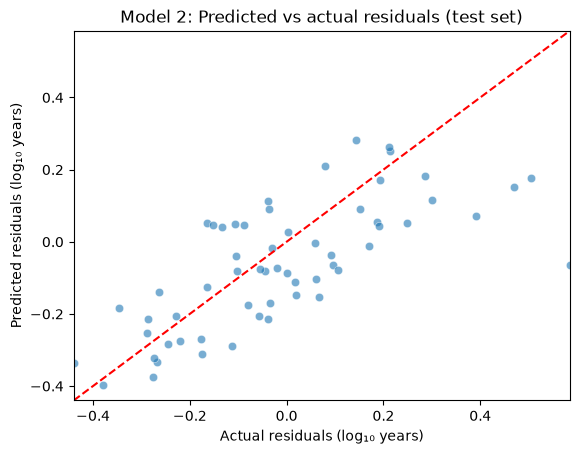

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x = y2_test, y = y2_pred_test, alpha = 0.6)

plot_min = min(y2_test.min(), y2_pred_test.min())
plot_max = max(y2_test.max(), y2_pred_test.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], color = 'red', linestyle = '--')
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)

plt.xlabel('Actual residuals (log₁₀ years)')
plt.ylabel('Predicted residuals (log₁₀ years)')
plt.title('Model 2: Predicted vs actual residuals (test set)')
plt.savefig('figures/model2_residuals_plot.png', dpi = 150)
plt.show()


In [42]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(best_model, X2_test, y2_test, n_repeats = 20,
                        random_state = 42, scoring = 'r2')

importance = pd.DataFrame({
    'feature' : X2_test.columns,
    'mean_importance' : imp.importances_mean,
    'std' : imp.importances_std
}).sort_values('mean_importance', ascending = False)

importance


,feature,mean_importance,std
2,Gestation/Incubation (days),0.157090,0.082257
7,Birth weight (g),0.080734,0.021141
0,Female maturity (days),0.031232,0.024046
4,Litter/Clutch size,0.026779,0.058730
8,Temperature (K),0.011706,0.020287
5,Litters/Clutches per year,0.011221,0.023868
6,Inter-litter/Interbirth interval,0.010277,0.016047
1,Male maturity (days),0.007086,0.028808
9,mass_specific_BMR,-0.001292,0.019274
3,Weaning (days),-0.004931,0.011221


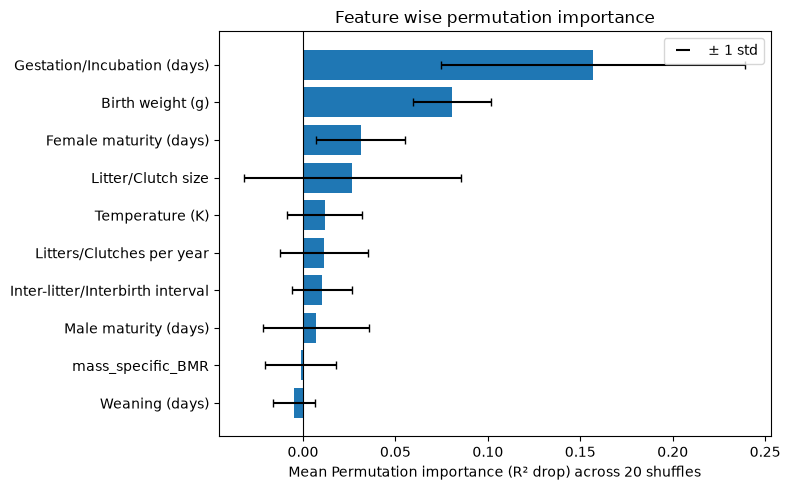

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (8,5))
importance_sorted = importance.sort_values('mean_importance')
ax.barh(y = importance_sorted['feature'], width = importance_sorted['mean_importance'],
       xerr = importance_sorted['std'], capsize = 3)
plt.xlabel('Mean Permutation importance (R² drop) across 20 shuffles')
ax.axvline(0, color = 'black', linewidth = 0.8)
ax.errorbar([], [], xerr = 1, fmt = 'none', color= 'black', capsize = 3, label = '± 1 std')
ax.legend(loc = 'upper right')
plt.title('Feature wise permutation importance')
plt.tight_layout()
plt.savefig('figures/permutation_importance.png', dpi = 150)
plt.show()

In [44]:
pd.DataFrame({'y2_pred_test': y2_pred_test}, index = X2_test.index).to_csv(
    'data/interim/model2_test_predictions.csv')


In [45]:
joblib.dump(pipe2, 'model2_pipe.pkl')

['model2_pipe.pkl']